In [ ]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "project_paths.py").exists():
    candidate = PROJECT_ROOT.parent
    if (candidate / "project_paths.py").exists():
        PROJECT_ROOT = candidate

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)


In [1]:
!pip install tensorflow scikit-learn -q

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

In [14]:
df = pd.read_csv("data/raw/Train_TEST.csv")  # adjust path if needed

print(df.head())
print(df["severity"].value_counts())

   ticket_id  customer_id         timestamp     location  pincode  \
0  TKT016402  CUST-651110  01-01-2023 00:06    Reinbazar   500023   
1  TKT011523  CUST-949032  01-01-2023 00:10   Anandnagar   500004   
2  TKT022439  CUST-569773  01-01-2023 00:17  Kattedan Ie   500077   
3  TKT036679  CUST-631193  01-01-2023 00:48   Moghalpura   500002   
4  TKT017066  CUST-449991  01-01-2023 01:16  Shyam Nagar   500004   

  complaint_type  severity                            grievance_text  \
0   Intermittent      High               please still keeps dropping   
1    No Internet  Critical     please facing no internet access yaar   
2   Router Issue       Low           please still router not working   
3    Packet Loss    Medium               facing data loss issue yaar   
4     Slow Speed  Very Low  INTERNET VERY SLOW SINCE MORNING!!! yaar   

                                    customer_address  
0     57, Mitter Nagar, Reinbazar, Hyderabad, 500023  
1                  71, Anandnagar, Hyderab

In [15]:
df = df.dropna(subset=["grievance_text", "severity"])

X = df["grievance_text"].astype(str)
y = df["severity"]

In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, range(len(le.classes_)))))

{'Critical': 0, 'High': 1, 'Low': 2, 'Medium': 3, 'Very Low': 4}


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [18]:
MAX_WORDS = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [19]:
import pickle

# Save tokenizer
with open("outputs/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved")

Tokenizer saved


In [21]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping



# 5. Tokenization
vocab_size = 10000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# 6. Build Bidirectional RNN Model (SimpleRNN as requested)
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),

    Bidirectional(SimpleRNN(64, return_sequences=True)),
    Bidirectional(SimpleRNN(32)),

    Dense(32, activation='relu'),   # NEW layer (stronger than tanh)
                       # prevents overfitting

    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])

# 7. Compile model
model.compile(
    loss='sparse_categorical_crossentropy',  # multi-class
    optimizer='adam',
    metrics=['accuracy']
)

# 8. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 9. Train model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

# 10. Evaluate
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

# 11. Predictions
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)



# 12. Save model
model.save("bilstm_complaint_model_v5class.h5")

print("\nModel training complete!")

Epoch 1/10
500/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 22s 33ms/step - accuracy: 0.4339 - loss: 0.9303 - val_accuracy: 0.4460 - val_loss: 0.8599
Epoch 2/10
500/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 15s 31ms/step - accuracy: 0.4417 - loss: 0.8514 - val_accuracy: 0.4295 - val_loss: 0.8478
Epoch 3/10
500/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 15s 31ms/step - accuracy: 0.4424 - loss: 0.8501 - val_accuracy: 0.4319 - val_loss: 0.8526
Epoch 4/10
500/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 31ms/step - accuracy: 0.4382 - loss: 0.8492 - val_accuracy: 0.4489 - val_loss: 0.8452
Epoch 5/10
500/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 15s 31ms/step - accuracy: 0.4367 - loss: 0.8567 - val_accuracy: 0.4265 - val_loss: 0.8527
Epoch 6/10
500/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 15s 31ms/step - accuracy: 0.4383 - loss: 0.8503 - val_accuracy: 0.4423


Model training complete!


In [22]:
import pickle

with open("outputs/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [23]:
# Convert text to sequences
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [24]:
# Predict probabilities
y_pred_probs = model.predict(X_test_pad)

# Convert to class index
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 3s 8ms/step


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n===== CONFUSION MATRIX =====\n")
print(confusion_matrix(y_test, y_pred))


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

    Critical       0.50      0.73      0.59      1474
        High       0.51      0.62      0.56      3175
         Low       0.00      0.00      0.00      1226
      Medium       0.34      0.47      0.40      2882
    Very Low       0.00      0.00      0.00      1243

    accuracy                           0.44     10000
   macro avg       0.27      0.36      0.31     10000
weighted avg       0.33      0.44      0.38     10000


===== CONFUSION MATRIX =====

[[1078  396    0    0    0]
 [1091 1982    0  102    0]
 [   0    0    0 1226    0]
 [   0 1531    0 1351    0]
 [   0    0    0 1243    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# Convert predictions back to labels
y_pred_labels = le.inverse_transform(y_pred)

# Compare actual vs predicted
results_df = pd.DataFrame({
    "Text": X_test.values,
    "Actual": le.inverse_transform(y_test),
    "Predicted": y_pred_labels
})

print(results_df.head(20))

                                           Text    Actual Predicted
0                  router keeps restarting yaar    Medium    Medium
1           NO CONNECTION SINCE MORNING!!! yaar      High  Critical
2            unstable connection from yesterday    Medium      High
3                    still data loss issue yaar    Medium      High
4                please internet very slow yaar  Very Low    Medium
5         please facing router keeps restarting    Medium    Medium
6                facing internet very slow yaar       Low    Medium
7   please cannot access websites since morning  Very Low    Medium
8          please router not working please fix    Medium    Medium
9        please speed is low since morning yaar    Medium    Medium
10                   please still no connection      High  Critical
11                    CANNOT ACCESS WEBSITES!!!       Low    Medium
12                      FACING PING TOO HIGH!!!      High      High
13        please facing internet very slow yaar 

In [30]:
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(pad)
    label = le.inverse_transform([np.argmax(pred)])

    return label[0]

# Example
print(predict_text("internet not working since morning please fix"))

1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 619ms/step
Critical


In [44]:
df=pd.read_csv("data/raw/Train_TEST.csv")

In [47]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/raw/Train_TEST.csv")   # change path if needed

# One-hot encode 'severity' with 0/1 directly
df_encoded = pd.get_dummies(df, columns=['severity'], dtype=int)

# Save the result
df_encoded.to_csv("data/processed/Train_TEST_onehot_numeric.csv", index=False)

# Preview
print(df_encoded.head())

   ticket_id  customer_id         timestamp     location  pincode  \
0  TKT016402  CUST-651110  01-01-2023 00:06    Reinbazar   500023   
1  TKT011523  CUST-949032  01-01-2023 00:10   Anandnagar   500004   
2  TKT022439  CUST-569773  01-01-2023 00:17  Kattedan Ie   500077   
3  TKT036679  CUST-631193  01-01-2023 00:48   Moghalpura   500002   
4  TKT017066  CUST-449991  01-01-2023 01:16  Shyam Nagar   500004   

  complaint_type                            grievance_text  \
0   Intermittent               please still keeps dropping   
1    No Internet     please facing no internet access yaar   
2   Router Issue           please still router not working   
3    Packet Loss               facing data loss issue yaar   
4     Slow Speed  INTERNET VERY SLOW SINCE MORNING!!! yaar   

                                    customer_address  severity_Critical  \
0     57, Mitter Nagar, Reinbazar, Hyderabad, 500023                  0   
1                  71, Anandnagar, Hyderabad, 500004          

In [48]:
df_agg = df.groupby(['pincode', 'timestamp']).sum().reset_index()

In [51]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/processed/Train_TEST_onehot_numeric.csv")

# Ensure timestamp is datetime
#df['timestamp'] = pd.to_datetime(df['timestamp'])

# -----------------------------
# 1. AUTO-DETECT ONE-HOT COLUMNS
# -----------------------------
# This is safer than startswith
onehot_cols = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

# Remove non-onehot numeric columns if present
exclude_cols = ['pincode']   # add more if needed
onehot_cols = [col for col in onehot_cols if col not in exclude_cols]

# -----------------------------
# 2. GROUP AND SUM
# -----------------------------
df_agg = df.groupby(['pincode', 'timestamp'])[onehot_cols].sum().reset_index()

# -----------------------------
# 3. SAVE
# -----------------------------
df_agg.to_csv("data/processed/Aggregated_output.csv", index=False)

print(df_agg.head())

   pincode         timestamp  severity_Critical  severity_High  severity_Low  \
0   500001  01-01-2023 13:21                  0              0             0   
1   500001  01-01-2023 18:59                  1              0             0   
2   500001  01-01-2024 17:57                  0              1             0   
3   500001  01-02-2023 16:26                  0              1             0   
4   500001  01-02-2024 16:39                  0              0             0   

   severity_Medium  severity_Very Low  
0                1                  0  
1                0                  0  
2                0                  0  
3                0                  0  
4                1                  0  


In [46]:
import pandas as pd

# Load your encoded dataset
#df = pd.read_csv("data/processed/Train_TEST_onehot_numeric.csv")

# If timestamp is not already datetime, specify the correct format
df['timestamp'] = pd.to_datetime(df['timestamp'], format="%d-%m-%Y %H:%M")

# -----------------------------
# 1. IDENTIFY ONE-HOT COLUMNS
# -----------------------------
# Assuming one-hot columns start with 'severity_'
onehot_cols = [col for col in df.columns if col.startswith('severity_')]

# -----------------------------
# 2. GROUP BY pincode + timestamp
# -----------------------------
df_agg = df.groupby(['pincode', 'timestamp'])[onehot_cols].sum().reset_index()

# -----------------------------
# 3. SAVE OUTPUT
# -----------------------------
df_agg.to_csv("data/processed/Aggregated_output.csv", index=False)

# Preview
print(df_agg.head())


   pincode           timestamp
0   500001 2023-01-01 13:21:00
1   500001 2023-01-01 18:59:00
2   500001 2023-01-02 23:40:00
3   500001 2023-01-03 00:39:00
4   500001 2023-01-03 05:43:00


In [43]:
df.head()

,ticket_id,customer_id,timestamp,location,pincode,complaint_type,severity,grievance_text,customer_address
0,TKT016402,CUST-651110,2023-01-01 00:06:00,Reinbazar,500023,Intermittent,High,please still keeps dropping,"57, Mitter Nagar, Reinbazar, Hyderabad, 500023"
1,TKT011523,CUST-949032,2023-01-01 00:10:00,Anandnagar,500004,No Internet,Critical,please facing no internet access yaar,"71, Anandnagar, Hyderabad, 500004"
2,TKT022439,CUST-569773,2023-01-01 00:17:00,Kattedan Ie,500077,Router Issue,Low,please still router not working,"09/91, Kattedan Ie, Hyderabad, 500077"
3,TKT036679,CUST-631193,2023-01-01 00:48:00,Moghalpura,500002,Packet Loss,Medium,facing data loss issue yaar,"H.No. 329, Acharya Zila, Hubliâ€“Dharwad-094212,..."
4,TKT017066,CUST-449991,2023-01-01 01:16:00,Shyam Nagar,500004,Slow Speed,Very Low,INTERNET VERY SLOW SINCE MORNING!!! yaar,"064, Mukherjee Marg, Kurnool-580143, Shyam Nag..."


In [49]:
df_agg.head()

,pincode,timestamp,ticket_id,customer_id,location,complaint_type,severity,grievance_text,customer_address
0,500001,01-01-2023 13:21,TKT028644,CUST-984343,Gandhi Bhawan,Intermittent,Medium,unstable connection since morning yaar,"205, Johal Road, Anantapur-766256, Gandhi Bhaw..."
1,500001,01-01-2023 18:59,TKT049196,CUST-582488,Gandhi Bhawan,No Internet,Critical,no internet access yaar,"491, Gandhi Bhawan, Hyderabad, 500001"
2,500001,01-01-2024 17:57,TKT031228,CUST-802695,Hyderabad.,High Latency,High,lag issue since morning,"H.No. 21, Sitaphalmandi, Hyderabad, 500061"
3,500001,01-02-2023 16:26,TKT026695,CUST-782384,Gandhi Bhawan,Intermittent,High,UNSTABLE CONNECTION FROM YESTERDAY!!! yaar,"H.No. 37, Gandhi Bhawan, Hyderabad, 500001"
4,500001,01-02-2024 16:39,TKT014885,CUST-737164,Gandhi Bhawan,Router Issue,Medium,please facing router keeps restarting,"H.No. 069, Gandhi Bhawan, Hyderabad, 500001"


In [65]:
import pandas as pd

# Load the data/processed/month_day_aggregated.csv file
df_combined = pd.read_csv('data/processed/month_day_aggregated.csv')

# Combine 'month' and 'day' into a new 'month_day' column
df_combined['month_day'] = df_combined['month'].astype(str) + '-' + df_combined['day'].astype(str)

# Display the head of the updated DataFrame
print(df_combined.head())

   month  day  severity_Critical  severity_High  severity_Low  \
0      1    1                 22             40            14   
1      1    2                 30             44            25   
2      1    3                 15             37            16   
3      1    4                 33             53            18   
4      1    5                 13             44            14   

   severity_Medium  severity_Very Low month_day  
0               35                 13       1-1  
1               39                 24       1-2  
2               54                 14       1-3  
3               46                 17       1-4  
4               42                 10       1-5  


In [67]:
df_combined.head()

,month,day,severity_Critical,severity_High,severity_Low,severity_Medium,severity_Very Low,month_day
0,1,1,22,40,14,35,13,1-1
1,1,2,30,44,25,39,24,1-2
2,1,3,15,37,16,54,14,1-3
3,1,4,33,53,18,46,17,1-4
4,1,5,13,44,14,42,10,1-5



Processing: severity_Critical


<Figure size 1200x800 with 0 Axes>

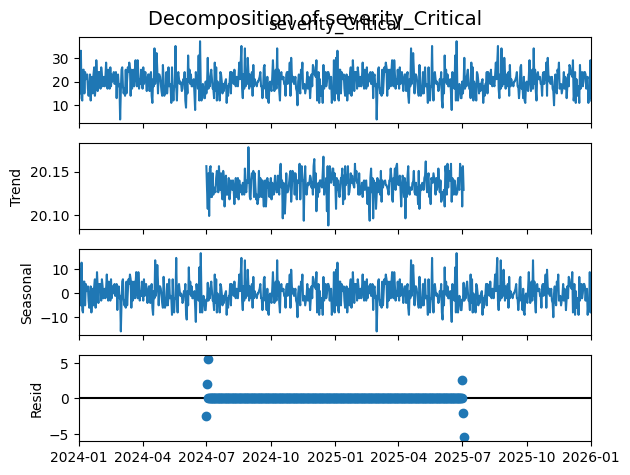


Processing: severity_High


<Figure size 1200x800 with 0 Axes>

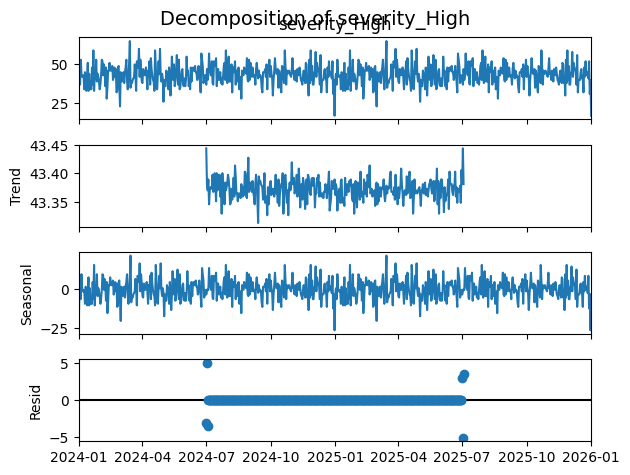


Processing: severity_Low


<Figure size 1200x800 with 0 Axes>

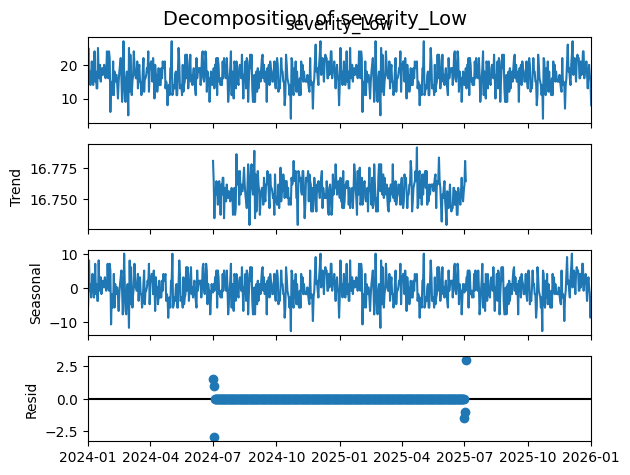


Processing: severity_Medium


<Figure size 1200x800 with 0 Axes>

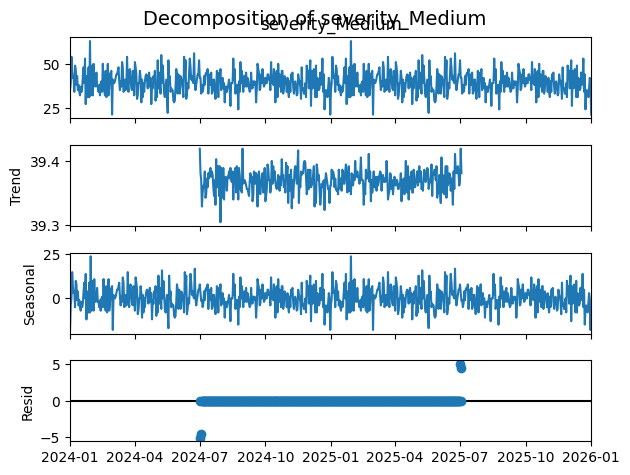


Processing: severity_Very Low


<Figure size 1200x800 with 0 Axes>

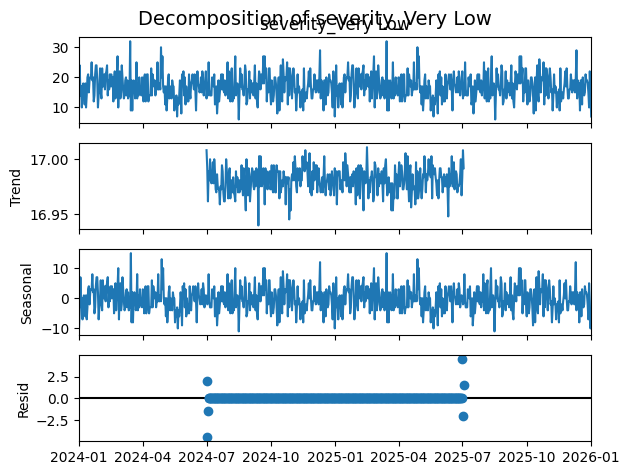

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')

# -----------------------------
# 2. CREATE TIME SERIES INDEX
# -----------------------------
# Assuming 'day_index' represents the day of the year (1-365/366)
start_date = '2024-01-01' # Choose a starting year for the time series (2024 is a leap year)
df['date'] = pd.to_datetime(start_date) + pd.to_timedelta(df['day_index'] - 1, unit='D')
df = df.sort_values('date')
df.set_index('date', inplace=True)

# -----------------------------
# 3. IDENTIFY SEVERITY COLUMNS
# -----------------------------
severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 4. STORE RESULTS
# -----------------------------
decomposition_results = {}

# -----------------------------
# 5. LOOP THROUGH EACH SEVERITY
# -----------------------------
for col in severity_cols:
    print(f"\nProcessing: {col}")

    ts = df[col]

    # Fix: duplicate to create 2 cycles
    ts_extended = pd.concat([ts, ts])

    # Create continuous date index
    ts_extended.index = pd.date_range(start='2024-01-01', periods=len(ts_extended), freq='D')

    # Decompose
    result = seasonal_decompose(ts_extended, model='additive', period=365)

    # Store results
    decomposition_results[col] = result

    # -----------------------------
    # 6. PLOT
    # -----------------------------
    plt.figure(figsize=(12,8))
    result.plot()
    plt.suptitle(f'Decomposition of {col}', fontsize=14)
    plt.show()

In [1]:
 import pandas as pd

# Load your dataset
df = pd.read_csv('data/processed/month_day_aggregated.csv')

# Sort properly (IMPORTANT before assigning serial numbers)
df = df.sort_values(['month', 'day']).reset_index(drop=True)

# Create serial day index (1 to N)
df['day_index'] = range(1, len(df) + 1)

# Drop month and day columns
df = df.drop(columns=['month', 'day'])

# Reorder columns (optional: keep day_index first)
cols = ['day_index'] + [col for col in df.columns if col != 'day_index']
df = df[cols]

# Save updated dataset
df.to_csv('data/processed/seasonal_index_data.csv', index=False)

# View result
df.head()

,day_index,severity_Critical,severity_High,severity_Low,severity_Medium,severity_Very Low
0,1,22,40,14,35,13
1,2,30,44,25,39,24
2,3,15,37,16,54,14
3,4,33,53,18,46,17
4,5,13,44,14,42,10


In [2]:
# Save file
df.to_csv('data/processed/seasonal_index_data.csv', index=False)




Plotting for: severity_Critical


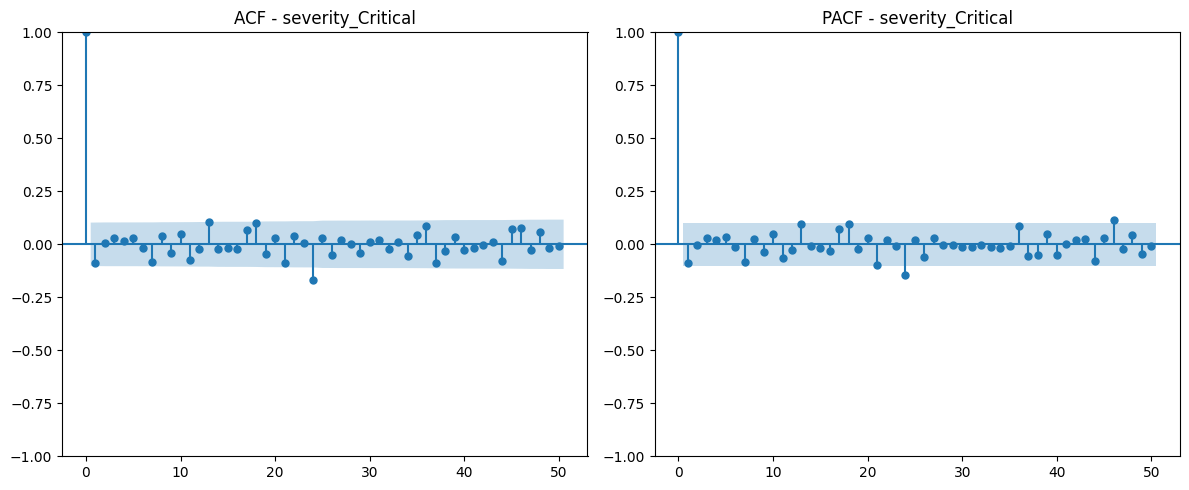


Plotting for: severity_High


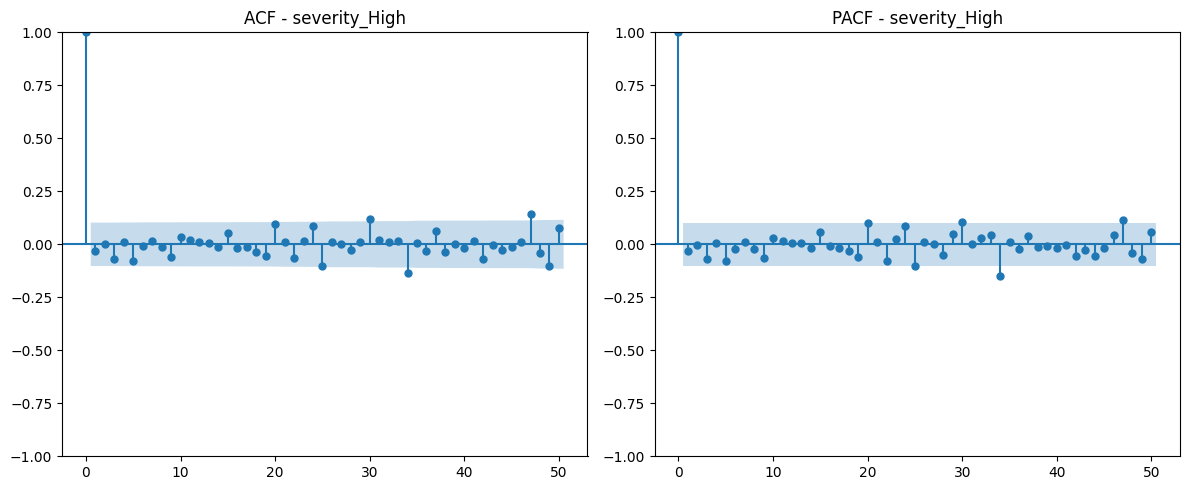


Plotting for: severity_Low


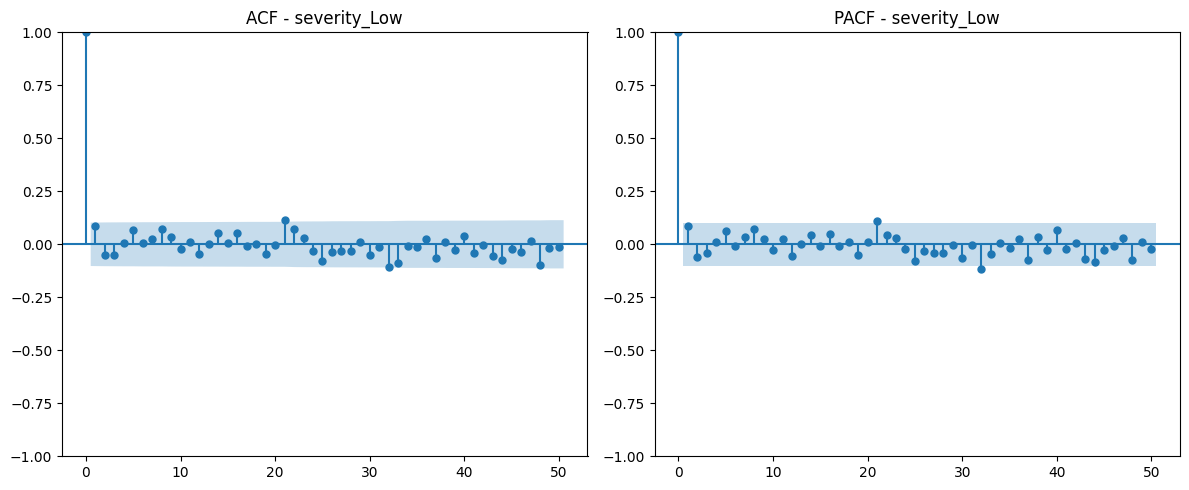


Plotting for: severity_Medium


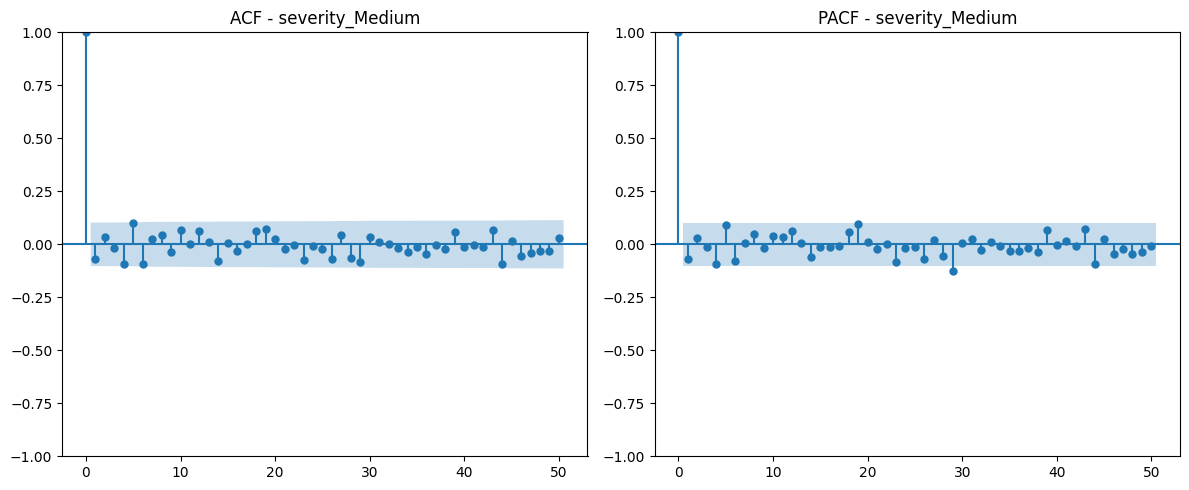


Plotting for: severity_Very Low


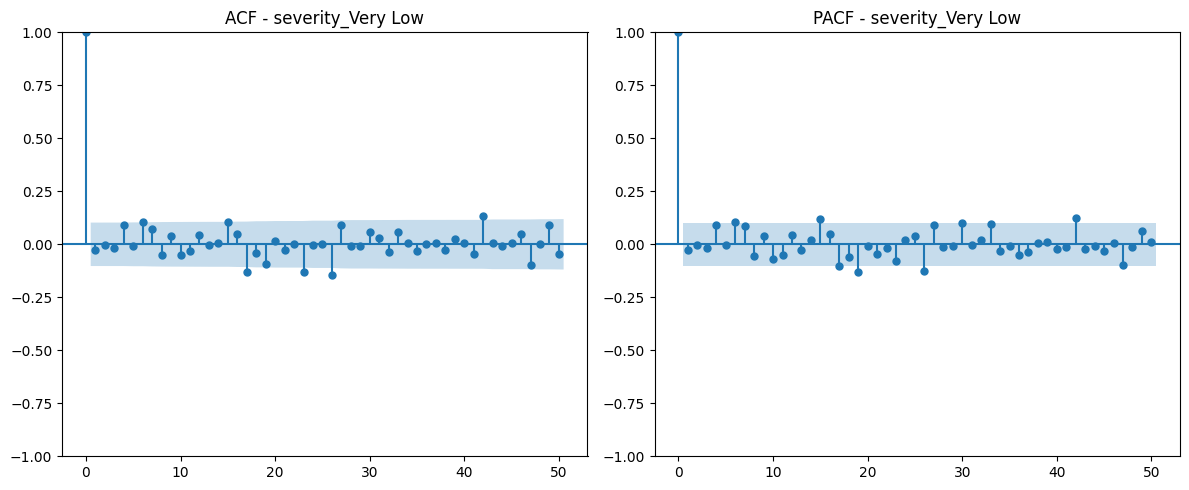

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')

# -----------------------------
# 2. SET INDEX (important)
# -----------------------------
df.set_index('day_index', inplace=True)

# -----------------------------
# 3. IDENTIFY SEVERITY COLUMNS
# -----------------------------
severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 4. LOOP THROUGH EACH COLUMN
# -----------------------------
for col in severity_cols:
    print(f"\nPlotting for: {col}")

    ts = df[col]

    plt.figure(figsize=(12,5))

    # ACF
    plt.subplot(1, 2, 1)
    plot_acf(ts, lags=50, ax=plt.gca())
    plt.title(f'ACF - {col}')

    # PACF
    plt.subplot(1, 2, 2)
    plot_pacf(ts, lags=50, method='ywm', ax=plt.gca())
    plt.title(f'PACF - {col}')

    plt.tight_layout()
    plt.show()


Processing: severity_Critical


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


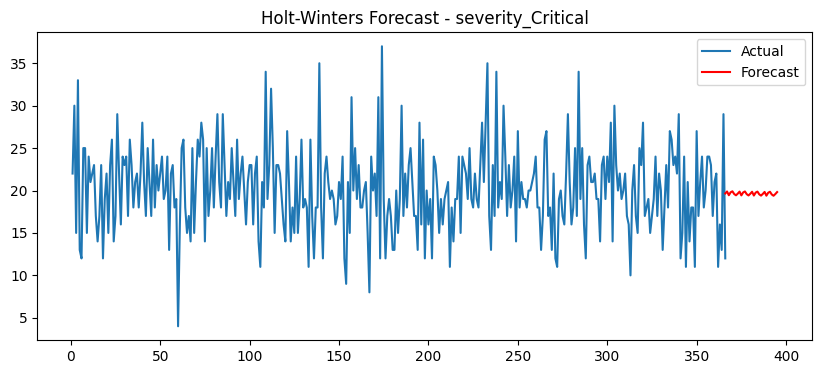


Processing: severity_High


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


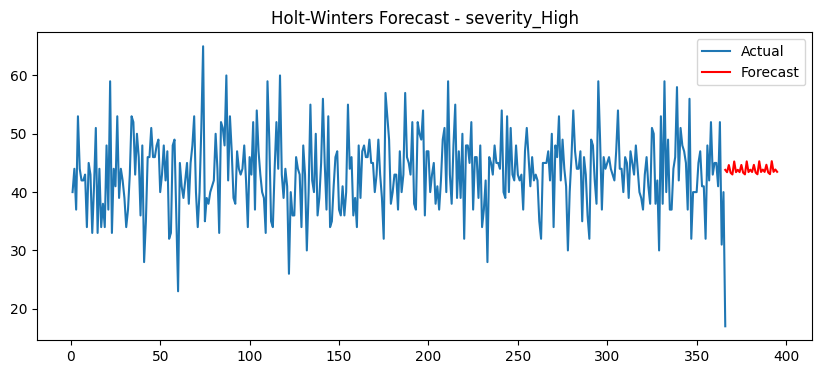


Processing: severity_Low


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


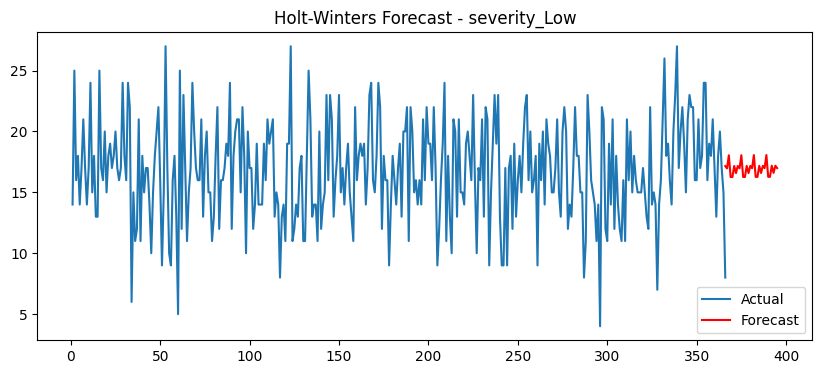


Processing: severity_Medium


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


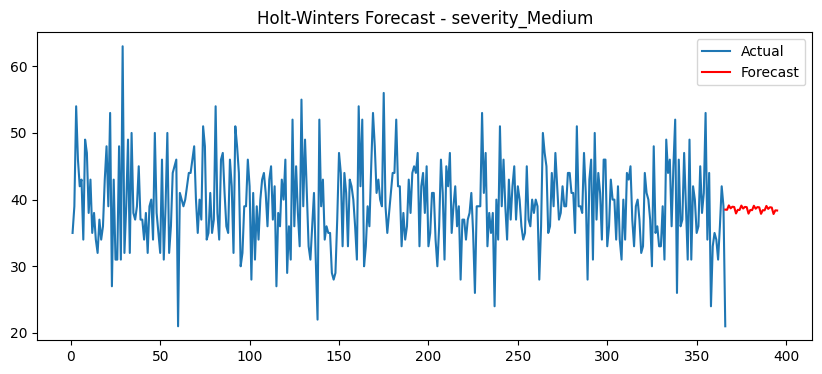


Processing: severity_Very Low


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


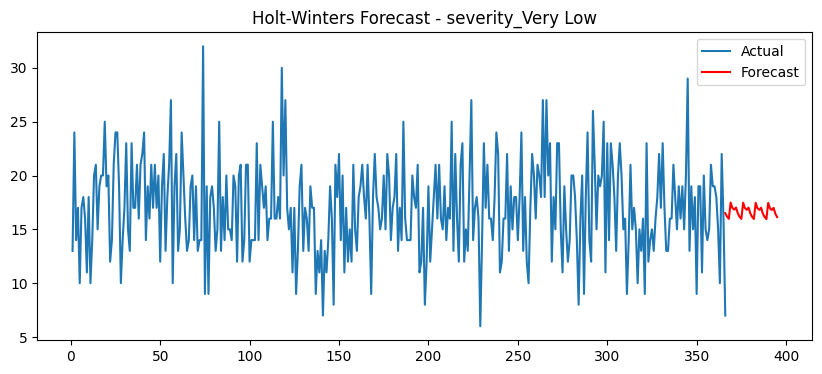

In [6]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')

# Set index
df.set_index('day_index', inplace=True)

# Identify severity columns
severity_cols = [col for col in df.columns if 'severity' in col]

# Store forecasts
forecast_results = {}

# -----------------------------
# 2. LOOP THROUGH EACH SEVERITY
# -----------------------------
for col in severity_cols:
    print(f"\nProcessing: {col}")

    ts = df[col]

    # -----------------------------
    # 3. FIT HOLT-WINTERS MODEL
    # -----------------------------
    model = ExponentialSmoothing(
        ts,
        trend='add',
        seasonal='add',
        seasonal_periods=7
    ).fit()

    # -----------------------------
    # 4. FORECAST (next 30 days)
    # -----------------------------
    forecast = model.forecast(30)

    forecast_results[col] = forecast

    # -----------------------------
    # 5. PLOT
    # -----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(ts, label='Actual')
    plt.plot(forecast, label='Forecast', color='red')
    plt.title(f'Holt-Winters Forecast - {col}')
    plt.legend()
    plt.show()

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# =============================
# EVALUATION FUNCTION
# =============================
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')
df.set_index('day_index', inplace=True)

severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 2. TRAIN-TEST SPLIT
# -----------------------------
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

# Store results
results = []

# -----------------------------
# 3. LOOP OVER EACH SEVERITY
# -----------------------------
for col in severity_cols:

    print(f"\nProcessing: {col}")

    y_train = train[col]
    y_test = test[col]

    # =============================
    # 1ï¸âƒ£ SEASONALITY MODEL (Naive)
    # =============================
    # Repeat last 7 days pattern
    seasonal_pattern = y_train[-7:].values
    seasonal_forecast = np.tile(seasonal_pattern, int(np.ceil(len(y_test)/7)))[:len(y_test)]

    # =============================
    # 2ï¸âƒ£ HOLT-WINTERS
    # =============================
    hw_model = ExponentialSmoothing(
        y_train,
        trend=None,
        seasonal='add',
        seasonal_periods=7
    ).fit()

    hw_forecast = hw_model.forecast(len(y_test))

    # =============================
    # 3ï¸âƒ£ ARIMA
    # =============================
    # Simple ARIMA (you can tune later)
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    sarima_model = SARIMAX(
        y_train,
        order=(1,1,0),              # same AR part
        seasonal_order=(1,1,1,7)    # (P,D,Q,s) â†’ weekly seasonality
    ).fit(disp=False)

    sarima_forecast = sarima_model.forecast(len(y_test))

    # Compute metrics
    mae_s, rmse_s = evaluate(y_test, seasonal_forecast)
    mae_hw, rmse_hw = evaluate(y_test, hw_forecast)
    mae_ar, rmse_ar = evaluate(y_test, sarima_forecast)

    # Store results
    results.append({
        'Severity': col,
        'Seasonal_MAE': mae_s,
        'Seasonal_RMSE': rmse_s,
        'HW_MAE': mae_hw,
        'HW_RMSE': rmse_hw,
        'ARIMA_MAE': mae_ar,
        'ARIMA_RMSE': rmse_ar
    })

# -----------------------------
# 4. RESULTS TABLE
# -----------------------------
results_df = pd.DataFrame(results)

print("\nFinal Comparison:")
print(results_df)

# Save results
results_df.to_csv('data/processed/model_comparison_results.csv', index=False)


Processing: severity_Critical

Processing: severity_High

Processing: severity_Low

Processing: severity_Medium

Processing: severity_Very Low

Final Comparison:
            Severity  Seasonal_MAE  Seasonal_RMSE    HW_MAE   HW_RMSE  \
0  severity_Critical      5.635135       6.844805  3.911589  4.809983   
1      severity_High      8.121622      10.149557  4.925024  6.805428   
2       severity_Low      4.743243       6.034809  3.458220  4.322957   
3    severity_Medium      7.540541       9.411034  5.305726  6.480717   
4  severity_Very Low      5.756757       7.118685  3.345206  4.177811   

   ARIMA_MAE  ARIMA_RMSE  
0   3.983359    4.878354  
1   6.844844    8.680593  
2   4.098964    5.142710  
3   5.417022    6.832399  
4   7.556684    8.612946  


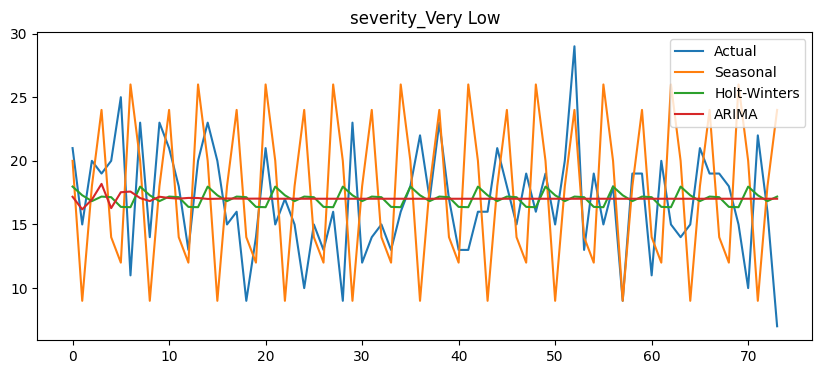

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual')
plt.plot(seasonal_forecast, label='Seasonal')
plt.plot(hw_forecast.values, label='Holt-Winters')
plt.plot(arima_forecast.values, label='ARIMA')
plt.legend()
plt.title(col)
plt.show()

In [14]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# -----------------------------
# 1. LOAD FULL DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')
df.set_index('day_index', inplace=True)

severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 2. FORECAST HORIZON
# -----------------------------
forecast_horizon = 30   # change to 7 / 14 / 60 as needed

# Store forecasts
final_forecasts = pd.DataFrame()

# -----------------------------
# 3. LOOP THROUGH EACH SEVERITY
# -----------------------------
for col in severity_cols:

    print(f"Forecasting: {col}")

    ts = df[col]

    # Fit Holt-Winters (best config from earlier)
    model = ExponentialSmoothing(
        ts,
        trend=None,
        seasonal='add',
        seasonal_periods=7
    ).fit()

    # Forecast
    forecast = model.forecast(forecast_horizon)

    final_forecasts[col] = forecast.values

# -----------------------------
# 4. ADD DAY INDEX FOR FUTURE
# -----------------------------
last_day = df.index.max()
future_days = range(last_day + 1, last_day + forecast_horizon + 1)

final_forecasts['day_index'] = future_days

# Reorder columns
cols = ['day_index'] + [col for col in final_forecasts.columns if col != 'day_index']
final_forecasts = final_forecasts[cols]

# -----------------------------
# 5. SAVE OUTPUT
# -----------------------------
final_forecasts.to_csv('data/processed/hw_forecast_results.csv', index=False)

print("\nForecast saved at: data/processed/hw_forecast_results.csv")
final_forecasts.head()

Forecasting: severity_Critical
Forecasting: severity_High
Forecasting: severity_Low
Forecasting: severity_Medium
Forecasting: severity_Very Low

Forecast saved at: data/processed/hw_forecast_results.csv


,day_index,severity_Critical,severity_High,severity_Low,severity_Medium,severity_Very Low
0,367,20.115183,43.346154,17.000000,39.211543,16.769231
1,368,20.346168,42.942311,16.807693,39.192307,16.442308
2,369,19.904036,44.173076,17.884617,39.846154,16.250000
3,370,20.250129,42.846156,16.096151,39.403842,17.750000
4,371,20.365434,42.557692,16.096157,39.653845,17.249999
